In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import os
import shutil

base_dir = '/content/drive/MyDrive/bccd_data'

# 2. La ruta a tu archivo CSV
labels_file = os.path.join(base_dir, 'bccd_labels.csv')

# 3. La ruta a tus imágenes originales
images_dir = os.path.join(base_dir, 'BCCD', 'JPEGImages')
#Código directo del reporte
labels_df = pd.read_csv(labels_file)

for i, row in labels_df.iterrows():
    # Asegura que el número tenga 5 dígitos
    image_number = int(row["Image"])
    filename = f"BloodImage_{image_number:05d}.jpg"

    class_labels = row["Category"].split(",")

    for class_label in class_labels:
        # Crear la carpeta de la clase WBC
        class_folder = os.path.join(base_dir, 'dataset_ordenado', class_label.strip())
        os.makedirs(class_folder, exist_ok=True)

        # Copiar la imagen
        image_path = os.path.join(images_dir, filename)
        destination_path = os.path.join(class_folder, filename)

        try:
            shutil.copy(image_path, destination_path)
            print(f'Imagen {filename} guardada en {class_label.strip()}')
        except FileNotFoundError:
            print(f'Error: No se encontró la imagen {image_path}')

dir_path = "/content/drive/MyDrive/bccd_data/dataset_ordenado"


Imagen BloodImage_00000.jpg guardada en WBC
Imagen BloodImage_00001.jpg guardada en WBC
Imagen BloodImage_00002.jpg guardada en WBC
Imagen BloodImage_00003.jpg guardada en WBC
Imagen BloodImage_00004.jpg guardada en WBC
Imagen BloodImage_00005.jpg guardada en WBC
Imagen BloodImage_00006.jpg guardada en WBC
Imagen BloodImage_00007.jpg guardada en WBC
Imagen BloodImage_00008.jpg guardada en WBC
Imagen BloodImage_00009.jpg guardada en WBC
Imagen BloodImage_00010.jpg guardada en WBC
Imagen BloodImage_00011.jpg guardada en WBC
Imagen BloodImage_00012.jpg guardada en WBC
Imagen BloodImage_00013.jpg guardada en WBC
Imagen BloodImage_00014.jpg guardada en WBC
Imagen BloodImage_00015.jpg guardada en WBC
Imagen BloodImage_00016.jpg guardada en WBC
Imagen BloodImage_00017.jpg guardada en WBC
Imagen BloodImage_00018.jpg guardada en WBC
Imagen BloodImage_00019.jpg guardada en WBC
Imagen BloodImage_00020.jpg guardada en WBC
Imagen BloodImage_00021.jpg guardada en WBC
Imagen BloodImage_00022.jpg guar

In [ ]:
import os
# Ruta actualizada apuntando a la carpeta de las clases
dir_path = "/content/drive/MyDrive/bccd_data/dataset_ordenado"

# Loop through each folder in the directory
for folder_name in os.listdir(dir_path):
    folder_path = os.path.join(dir_path, folder_name)

    # Check if this path is a directory
    if os.path.isdir(folder_path):
        # Count the number of files in this folder
        file_count = len(os.listdir(folder_path))

        # Print the folder name and file count
        print(f"{folder_name}: {file_count}")

WBC: 358


In [ ]:
import os
import numpy as np
from PIL import Image

data_dir = '/content/drive/MyDrive/bccd_data/dataset_ordenado/WBC'

def load_images():
    images = []

    # Aseguramos que solo lea archivos de imagen válidos
    # y evitamos cualquier archivo oculto del sistema
    archivos = [f for f in os.listdir(data_dir) if f.endswith('.jpg')]

    for filename in archivos:
        img_path = os.path.join(data_dir, filename)

        try:
            # 1. Abrir imagen
            img = Image.open(img_path)

            # 2. Convertir a RGB
            img = img.convert('RGB')

            # 3. Redimensionar 64 x 64
            img = img.resize((64, 64))

            # 4. Convertir a matriz matemática
            img_array = np.asarray(img)
            images.append(img_array)

        except Exception as e:
            print(f"Error procesando {filename}: {e}")

    # Convertir la lista completa en un tensor 4D de NumPy
    # Forma resultante: (Num_Imagenes, Altura, Anchura, Canales) -> (358, 256, 256, 3)
    return np.asarray(images)

# Ejecutamos la función y guardamos el resultado
wbc_array = load_images()

print(f"Dimensiones del arreglo cargado: {wbc_array.shape}")

Dimensiones del arreglo cargado: (358, 64, 64, 3)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Reshape, Conv2D, BatchNormalization, UpSampling2D, Activation

# Define the generator architecture
def build_generator(latent_dim, img_shape):
    model = Sequential()

    # Capa de entrada (Mapeo del espacio latente)
    model.add(Dense(128 * int(img_shape[0] / 4) * int(img_shape[1] / 4), activation="relu", input_dim=latent_dim))
    model.add(Reshape((int(img_shape[0] / 4), int(img_shape[1] / 4), 128)))

    # Primer bloque de expansión
    model.add(UpSampling2D())
    model.add(Conv2D(256, kernel_size=3, padding="same"))
    model.add(BatchNormalization(momentum=0.8))
    model.add(Activation("relu"))

    # Segundo bloque de expansión
    model.add(UpSampling2D())
    model.add(Conv2D(128, kernel_size=3, padding="same"))
    model.add(BatchNormalization(momentum=0.8))
    model.add(Activation("relu"))

    # Capa de salida (Generación de la imagen final)
    model.add(Conv2D(img_shape[2], kernel_size=3, padding='same'))
    # Tanh
    model.add(Activation("tanh"))

    return model

# Ejemplo
dimension_latente = 100
forma_imagen = (64, 64, 3)

generador = build_generator(dimension_latente, forma_imagen)
generador.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32768)          │     3,309,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 3)      │         3,459 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 3)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,904,771 (14.90 MB)

 Trainable params: 3,904,003 (14.89 MB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dropout, ZeroPadding2D, BatchNormalization, LeakyReLU, Dense

def build_discriminator(img_shape):
    model = Sequential()

    # Bloque 1: Entrada de la imagen
    model.add(Conv2D(32, kernel_size=(3, 3), strides=(2, 2), padding='same', input_shape=img_shape))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(0.25))

    # Bloque 2
    model.add(Conv2D(64, kernel_size=(3, 3), strides=(2, 2), padding='same'))
    # Nota: Este ZeroPadding asimétrico ayuda a cuadrar dimensiones si tu imagen inicial
    # no es una potencia de 2 perfecta
    model.add(ZeroPadding2D(padding=((0,1),(0,1))))
    model.add(BatchNormalization(momentum=0.8))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(0.25))

    # Bloque 3
    model.add(Conv2D(128, kernel_size=(3, 3), strides=(2, 2), padding='same'))
    model.add(BatchNormalization(momentum=0.8))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(0.25))

    # Bloque 4
    model.add(Conv2D(256, kernel_size=(3, 3), strides=(1, 1), padding='same'))
    model.add(BatchNormalization(momentum=0.8))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(0.25))

    # Aplanamiento y salida escalar
    model.add(Flatten())
    # La salida Sigmoide nos da un valor entre 0 y 1
    model.add(Dense(1, activation='sigmoid'))

    return model

# Ejemplo
forma_imagen = (64, 64, 3)
discriminador = build_discriminator(forma_imagen)
discriminador.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d (ZeroPadding2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 17, 17, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 9, 9, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 9, 9, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 9, 9, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 9, 9, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        20,737 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 410,945 (1.57 MB)

 Trainable params: 410,049 (1.56 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
# 1. Pérdida del Discriminador
def discriminator_loss(real_output, fake_output):

    real_loss = cross_entropy(tf.ones_like(real_output), real_output)


    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)


    total_loss = real_loss + fake_loss
    return total_loss

# 2. Pérdida del Generador
def generator_loss(fake_output):

    return cross_entropy(tf.ones_like(fake_output), fake_output)

In [ ]:
import tensorflow as tf

BATCH_SIZE = 128
LATENT_DIM = 100
EPOCHS = 2000
img_shape = (64, 64, 3)

images = load_images()
images = (images.astype('float32') - 127.5) / 127.5
dataset = tf.data.Dataset.from_tensor_slices(images).shuffle(len(images)).batch(BATCH_SIZE)

In [ ]:
generator = build_generator(LATENT_DIM, img_shape)
discriminator = build_discriminator(img_shape)

cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

# Actualizamos el learning rate a 0.0002 y agregamos beta_1=0.5
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

In [ ]:
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    # Usamos el objeto cross_entropy instanciado arriba
    return cross_entropy(tf.ones_like(fake_output), fake_output)

In [ ]:
@tf.function
def train_step(images):
    current_batch_size = tf.shape(images)[0]
    noise = tf.random.normal([current_batch_size, LATENT_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

def train(dataset, epochs):
    for epoch in range(epochs):
        for batch in dataset:
            gen_loss, disc_loss = train_step(batch)

        print(f'Epoch {epoch+1}, Generator Loss: {gen_loss:.4f}, Discriminator Loss: {disc_loss:.4f}')

In [ ]:
train(dataset, EPOCHS)

Epoch 1, Generator Loss: 2.2513, Discriminator Loss: 0.3846
Epoch 2, Generator Loss: 3.4170, Discriminator Loss: 0.6554
Epoch 3, Generator Loss: 5.3168, Discriminator Loss: 0.5113
Epoch 4, Generator Loss: 0.8295, Discriminator Loss: 0.9974
Epoch 5, Generator Loss: 1.5014, Discriminator Loss: 0.5714
Epoch 6, Generator Loss: 2.4525, Discriminator Loss: 0.3864
Epoch 7, Generator Loss: 5.7181, Discriminator Loss: 2.0558
Epoch 8, Generator Loss: 1.4314, Discriminator Loss: 0.5488
Epoch 9, Generator Loss: 6.0176, Discriminator Loss: 0.0321
Epoch 10, Generator Loss: 6.1314, Discriminator Loss: 0.6267
Epoch 11, Generator Loss: 3.3345, Discriminator Loss: 0.5351
Epoch 12, Generator Loss: 5.5257, Discriminator Loss: 0.0447
Epoch 13, Generator Loss: 3.8522, Discriminator Loss: 0.1307
Epoch 14, Generator Loss: 9.3422, Discriminator Loss: 0.2696
Epoch 15, Generator Loss: 1.2070, Discriminator Loss: 0.6132
Epoch 16, Generator Loss: 11.3496, Discriminator Loss: 0.1445
Epoch 17, Generator Loss: 6.6752

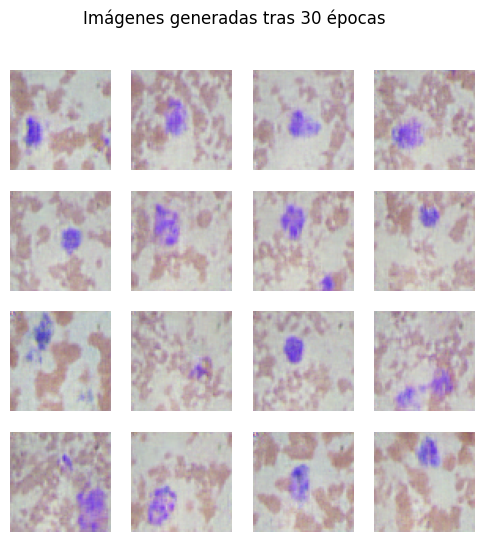

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf

def generate_and_plot_images(model, epoch, test_input):
    # training=False es clave aquí para que capas como BatchNormalization o Dropout
    # se comporten en modo de inferencia y no de entrenamiento.
    predictions = model(test_input, training=False)

    # Creamos una figura con una cuadrícula de 4x4 (para mostrar 16 imágenes)
    fig = plt.figure(figsize=(6, 6))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)

        # Desnormalización:

        img = predictions[i] * 0.5 + 0.5

        plt.imshow(img)
        plt.axis('off')

    plt.suptitle(f'Imágenes generadas tras {epoch} épocas')
    plt.show()

# --- Ejecución de la celda ---

# Generamos ruido aleatorio para crear 16 imágenes nuevas
num_examples_to_generate = 16
# Usamos la misma LATENT_DIM que se definió en la función de entrenamiento
random_vector_for_generation = tf.random.normal([num_examples_to_generate, LATENT_DIM])

# Llamamos a la función al generador ya entrenado
generate_and_plot_images(generator, 30, random_vector_for_generation)

Entre los usos que se la da a Colab en la comunidad de aprendizaje automático, se encuentran los siguientes:
- Introducción a TensorFlow
- Desarrollo y entrenamiento de redes neuronales
- Experimentación con TPU
- Diseminación de investigación de IA
- Creación de instructivos

Para ver notebooks de Colab de ejemplo que muestran los usos del aprendizaje automático, consulta los <a href="#machine-learning-examples">ejemplos</a> que se incluyen a continuación.

<div class="markdown-google-sans">

## Más recursos

### Cómo trabajar con notebooks en Colab

</div>

- [Descripción general de Colab](/notebooks/basic_features_overview.ipynb)
- [Guía para usar Markdown](/notebooks/markdown_guide.ipynb)
- [Cómo importar bibliotecas y luego instalar dependencias](/notebooks/snippets/importing_libraries.ipynb)
- [Cómo guardar y cargar notebooks en GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Formularios interactivos](/notebooks/forms.ipynb)
- [Widgets interactivos](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Cómo trabajar con datos
</div>

- [Cómo cargar datos: Drive, Hojas de cálculo y Google Cloud Storage](/notebooks/io.ipynb)
- [Gráficos: visualización de datos](/notebooks/charts.ipynb)
- [Cómo comenzar a usar BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Aprendizaje automático

<div>

Estos son algunos de los notebooks relacionados con el aprendizaje automático; incluido el curso de aprendizaje automático en línea de Google. Para obtener más información, consulta el <a href="https://developers.google.com/machine-learning/crash-course/">sitio web del curso completo</a>.
- [Introducción a Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Introducción a RAPIDS cuDF para acelerar Pandas](https://nvda.ws/rapids-cudf)
- [Comenzar a usar el modo de acelerador de cuML](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Uso de aceleración de hardware
</div>

- [Entrena una CNN para clasificar dígitos escritos a mano en el conjunto de datos MNIST con la API de Flax NNX](https://colab.research.google.com/github/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)
- [Entrena un Vision Transformer &#40;ViT&#41; para la clasificación de imágenes con JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_Vision_transformer.ipynb)
- [Clasificación de texto con un modelo de lenguaje de Transformer con JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_transformer_text_classification.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Ejemplos destacados

</div>

- <a href="https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html">Entrena un modelo de lenguaje miniGPT con JAX AI Stack</a>
- <a href="https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb">Ajuste de LoRA o QLoRA para LLM con Tunix</a>
- <a href="https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/">Ajuste eficiente de parámetros de Gemma con LoRA y QLoRA</a>
- <a href="https://keras.io/keras_hub/guides/hugging_face_keras_integration/">Cargando puntos de control de Transformers de Hugging Face</a>
- <a href="https://keras.io/guides/int8_quantization_in_keras/">Cuantización de números enteros de 8 bits en Keras</a>
- <a href="https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/">Entrenamiento e inferencia de Float8 con un modelo de Transformer simple</a>
- <a href="https://keras.io/keras_hub/guides/transformer_pretraining/">Entrenamiento previo de un Transformer desde cero con KerasHub</a>
- <a href="https://keras.io/examples/vision/mnist_convnet/">Red convolucional simple basada en MNIST</a>
- <a href="https://keras.io/examples/vision/image_classification_from_scratch/">Clasificación de imágenes desde cero con Keras 3</a>
- <a href="https://keras.io/keras_hub/guides/classification_with_keras_hub/">Clasificación de imágenes con KerasHub</a>
